# Classification Algorithms

## Breast Cancer Dataset — Logistic Regression, Trees, Ensembles, SVM, KNN, Naive Bayes

**Dataset:** `sklearn.datasets.load_breast_cancer` — 569 samples, 30 numeric features.
Target is binary: malignant (0) vs benign (1).

**Goal:** Understand how different classification algorithms approach the same problem,
where each one fits best, and how to evaluate them beyond simple accuracy — particularly
when the cost of false negatives is high.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Models, metrics, preprocessing |

## Setup and Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")

All imports successful.


## Load and Prepare the Dataset

Loading Breast Cancer directly from sklearn. The dataset is clean with no missing
values. Preparation focuses on understanding class balance, feature distributions,
and setting up the train/test split before any model is fitted.

In [3]:
cancer = load_breast_cancer(as_frame=True)

df = cancer.frame
print(f"Shape: {df.shape}")
print(f"\nTarget classes: {cancer.target_names}")
print(f"Target distribution:\n{df['target'].value_counts()}")
print(f"\nClass balance: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

Shape: (569, 31)

Target classes: ['malignant' 'benign']
Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Class balance: {1: 0.627, 0: 0.373}


In [4]:
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


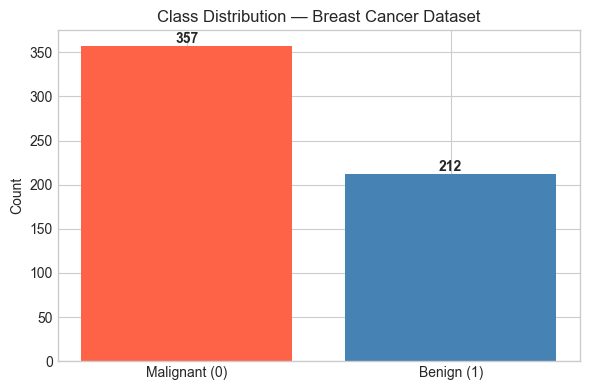

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df["target"].value_counts()
ax.bar(
    ["Malignant (0)", "Benign (1)"],
    counts.values,
    color=["tomato", "steelblue"]
)
ax.set_title("Class Distribution — Breast Cancer Dataset")
ax.set_ylabel("Count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

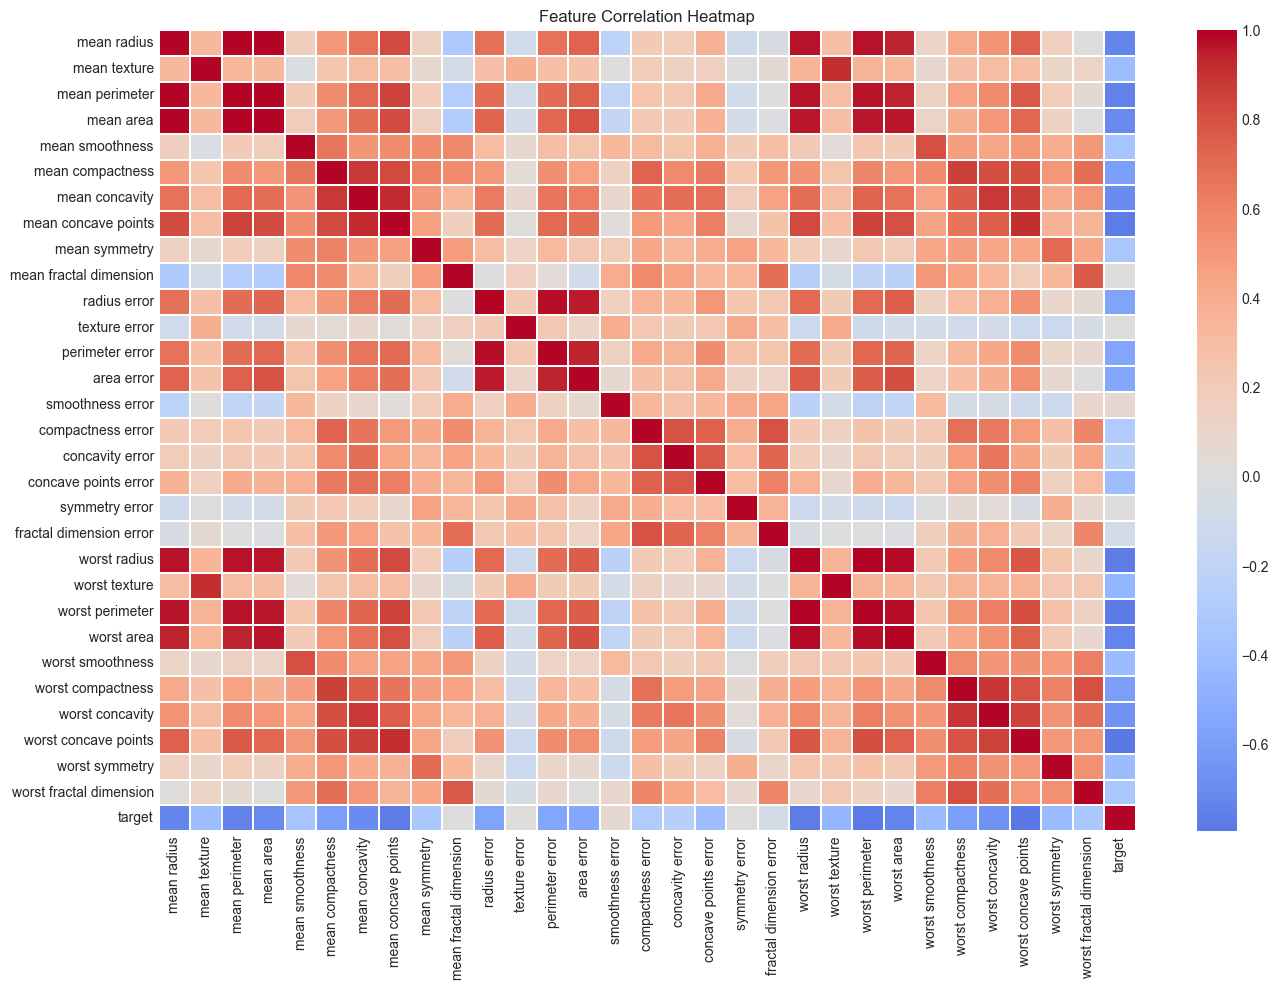

In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}  X_test: {X_test_scaled.shape}")
print(f"\nTrain class balance: {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {pd.Series(y_test).value_counts(normalize=True).round(3).to_dict()}")

X_train: (455, 30)  X_test: (114, 30)

Train class balance: {1: 0.626, 0: 0.374}
Test  class balance: {1: 0.632, 0: 0.368}


**Observations**

- Dataset is moderately imbalanced — ~63% benign, ~37% malignant. Not severe enough
  to require resampling but means accuracy alone can be misleading. A model predicting
  benign always would score 63% accuracy while being dangerously wrong on all malignant cases
- Several feature groups are highly correlated — mean, standard error, and worst-case
  measurements exist for each of the 10 base features. This multicollinearity will
  affect Logistic Regression and SVM more than tree-based models
- `stratify=y` in the split ensures both train and test sets preserve the same class
  ratio — important for reliable evaluation on imbalanced data
- All features are scaled — required for Logistic Regression, SVM, and KNN which are
  sensitive to feature magnitudes. Tree-based models and Naive Bayes do not need it
  but scaling does not hurt them

## Logistic Regression

Despite the name, Logistic Regression is a classification algorithm. It models the
probability that a sample belongs to a class using the sigmoid function, which
squashes any linear combination of features into a [0, 1] range.

    P(y=1) = 1 / (1 + e^(-z))     where z = w1x1 + w2x2 + ... + wnxn + b

A probability above 0.5 is classified as benign (1), below as malignant (0).
The decision boundary is the hyperplane where predicted probability equals exactly 0.5.

Logistic Regression is a strong baseline — fast, interpretable, and performs well
when the relationship between features and the log-odds of the target is approximately
linear.

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr    = lr.predict(X_test_scaled)
y_prob_lr    = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Accuracy: 0.9825


### Coefficient Analysis

Each coefficient represents the change in log-odds of being benign for a one
standard deviation increase in that feature. Large positive coefficients push
the prediction toward benign, large negative toward malignant.

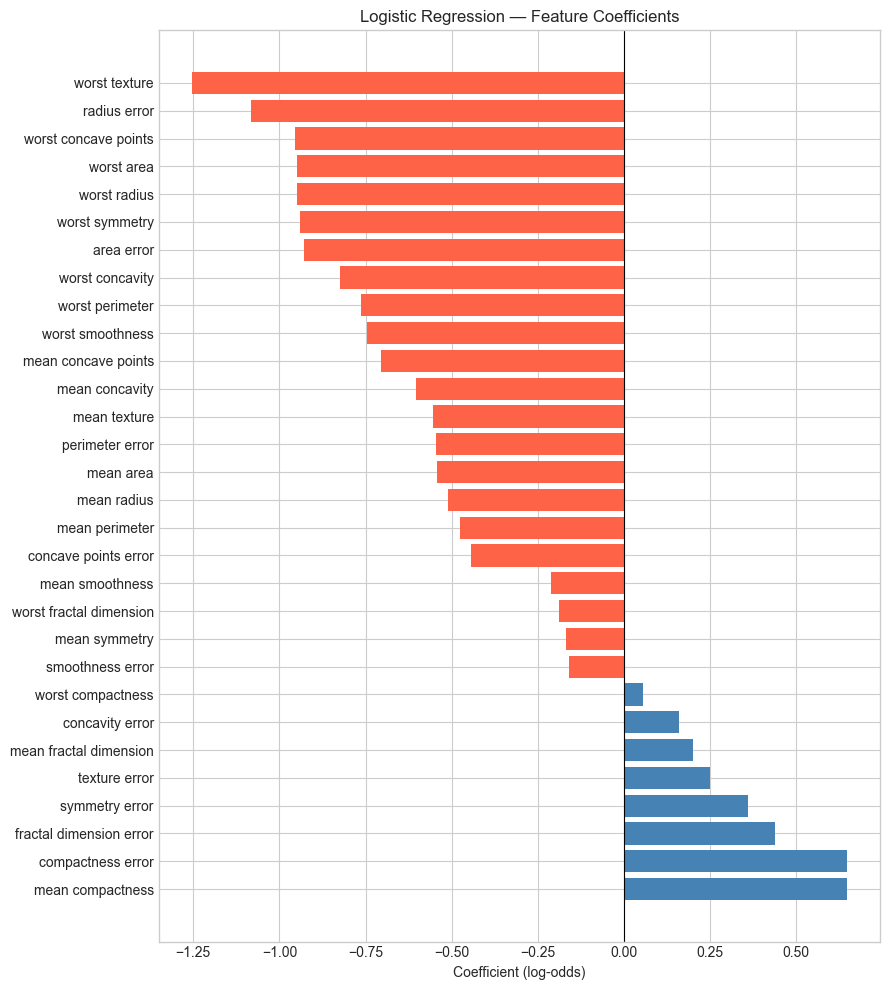

In [9]:
coef_df = pd.DataFrame({
    "feature":     X.columns,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ["steelblue" if c > 0 else "tomato" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Feature Coefficients")
ax.set_xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

### Predicted Probability Distribution

A confident model produces probabilities clustered near 0 and 1. Probabilities
clustered near 0.5 indicate the model is uncertain — these are the cases most
likely to be misclassified.

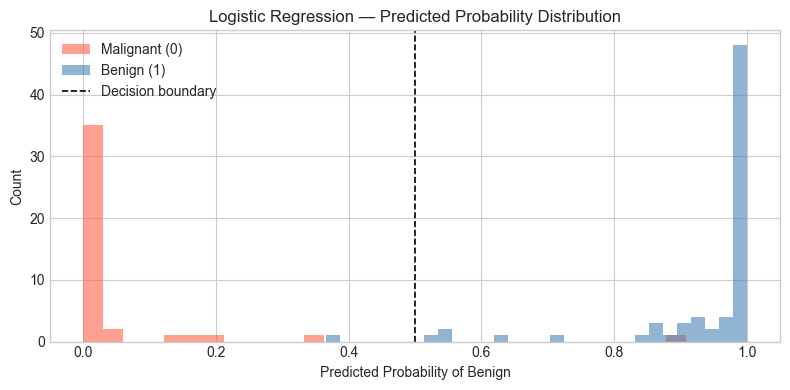

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(y_prob_lr[y_test == 0], bins=30, alpha=0.6,
        color="tomato", label="Malignant (0)")
ax.hist(y_prob_lr[y_test == 1], bins=30, alpha=0.6,
        color="steelblue", label="Benign (1)")
ax.axvline(0.5, color="black", linewidth=1.2, linestyle="--", label="Decision boundary")
ax.set_xlabel("Predicted Probability of Benign")
ax.set_ylabel("Count")
ax.set_title("Logistic Regression — Predicted Probability Distribution")
ax.legend()
plt.tight_layout()
plt.show()

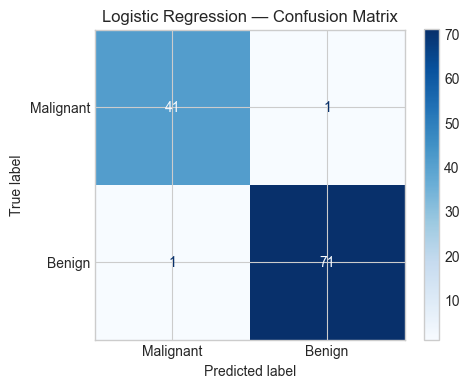

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1:        0.9861
ROC-AUC:   0.9954


**Observations**

- Logistic Regression performs strongly on this dataset — the linear decision
  boundary is sufficient because the classes are well-separated in feature space
- The probability distribution shows clear separation between malignant and benign
  predictions — most probabilities are near 0 or 1, indicating high model confidence
- Features with large negative coefficients (pushing toward malignant) are worth
  noting clinically — these are the measurements most associated with malignancy
  in this linear model
- In a medical context, recall on the malignant class is the critical metric —
  a false negative (predicting benign when actually malignant) is far more costly
  than a false positive. We will revisit this tradeoff in the metrics section

## Decision Tree

A Decision Tree splits the data recursively on feature thresholds, choosing at each
node the split that best separates the classes. The result is a set of if-else rules
that are fully interpretable — you can trace exactly why any prediction was made.

The key hyperparameter is `max_depth`. An unconstrained tree will grow until every
leaf is pure — perfectly fitting training data but memorising noise. Constraining
depth controls the bias-variance tradeoff directly.

In [13]:
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_scaled, y_train)

y_pred_dt_full = dt_full.predict(X_test_scaled)

print(f"Max depth reached:  {dt_full.get_depth()}")
print(f"Number of leaves:   {dt_full.get_n_leaves()}")
print(f"Train accuracy:     {accuracy_score(y_train, dt_full.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy:     {accuracy_score(y_test,  y_pred_dt_full):.4f}")

Max depth reached:  7
Number of leaves:   19
Train accuracy:     1.0000
Test  accuracy:     0.9123


### Depth vs Accuracy

Sweeping `max_depth` from 1 to 15 to find where train and test accuracy diverge.
The point of divergence is where the tree starts memorising training data.

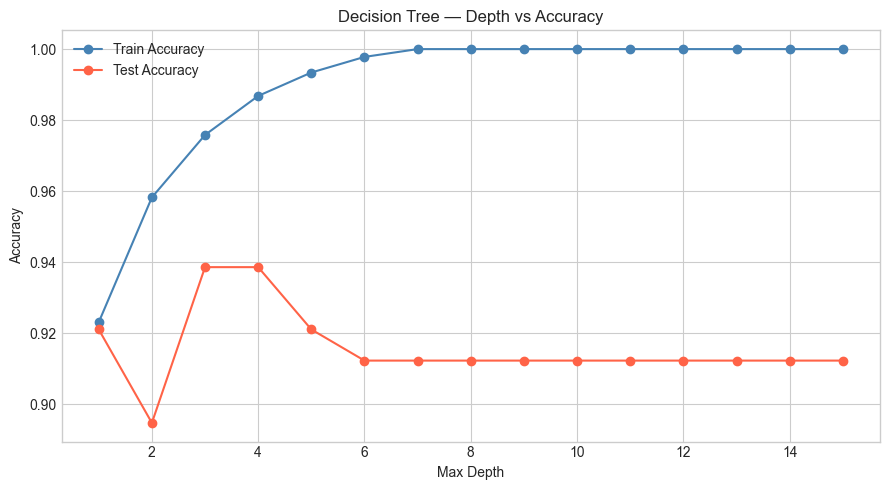

In [14]:
depths        = list(range(1, 16))
train_scores  = []
test_scores   = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,  dt.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_scores, marker="o", color="steelblue", label="Train Accuracy")
ax.plot(depths, test_scores,  marker="o", color="tomato",    label="Test Accuracy")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree — Depth vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

### Constrained Tree

Fitting with the depth that produced the best test accuracy in the sweep above.
A shallower tree is also more interpretable — each additional level doubles the
number of rules.

In [15]:
best_depth = depths[test_scores.index(max(test_scores))]
print(f"Best depth from sweep: {best_depth}")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt   = dt.predict(X_test_scaled)
y_prob_dt   = dt.predict_proba(X_test_scaled)[:, 1]

print(f"Train accuracy: {accuracy_score(y_train, dt.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test,  y_pred_dt):.4f}")

Best depth from sweep: 3
Train accuracy: 0.9758
Test  accuracy: 0.9386


### Tree Visualisation

Each node shows the split condition, gini impurity, sample count, and class
distribution. Tracing a path from root to leaf is the full explanation for
any individual prediction.

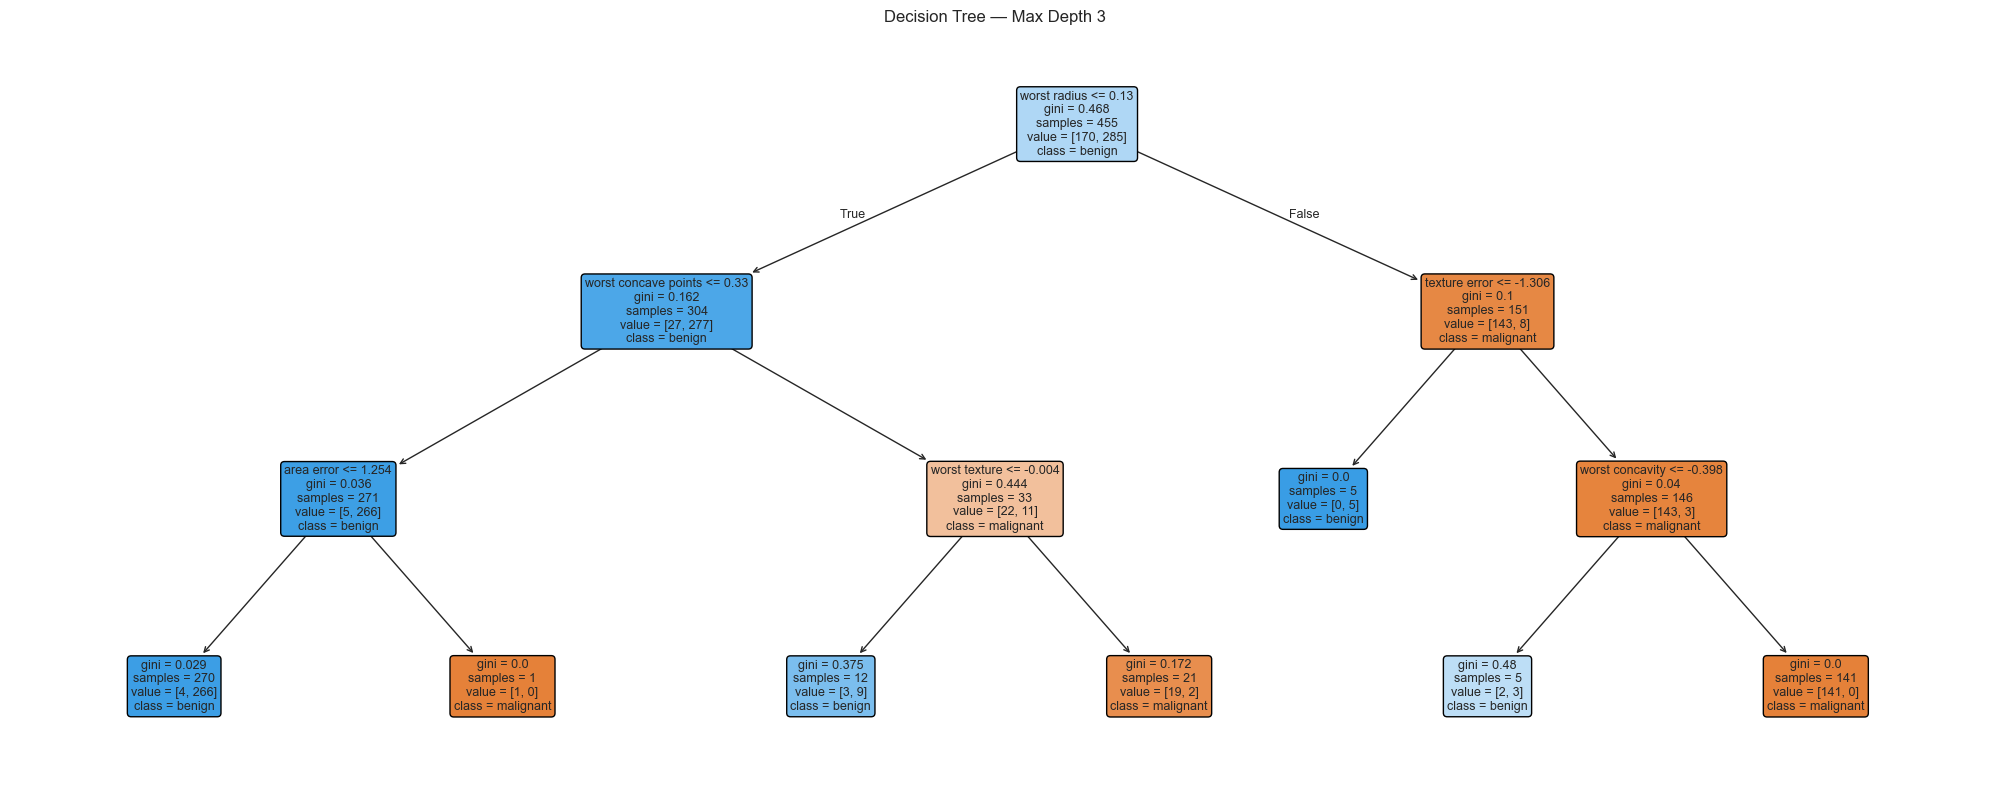

In [16]:
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title(f"Decision Tree — Max Depth {best_depth}")
plt.tight_layout()
plt.show()

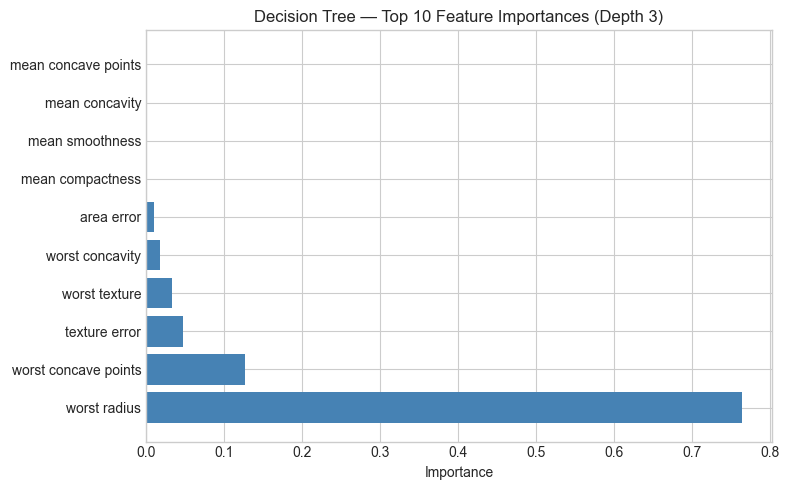

In [17]:
importance_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
ax.set_title(f"Decision Tree — Top 10 Feature Importances (Depth {best_depth})")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

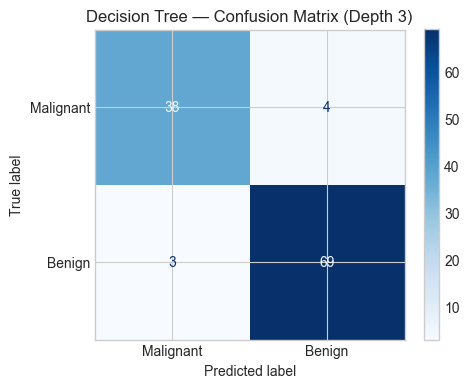

Accuracy:  0.9386
Precision: 0.9452
Recall:    0.9583
F1:        0.9517
ROC-AUC:   0.9446


In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Decision Tree — Confusion Matrix (Depth {best_depth})")
plt.tight_layout()
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

**Observations**

- The unconstrained tree reaches full depth and achieves perfect train accuracy —
  a clear sign of memorisation. Test accuracy is lower, confirming overfitting
- The depth sweep shows test accuracy peaks early and then plateaus or drops —
  the optimal depth is much shallower than what the unconstrained tree grows to
- Decision Trees are the most interpretable model in this notebook — the visualisation
  shows exactly which feature and threshold drove each split
- Feature importance from a single tree can be unstable — a small change in data
  can produce a completely different set of top features. Random Forest addresses
  this by averaging importance across many trees

## Random Forest

A Random Forest builds many Decision Trees in parallel, each trained on a random
bootstrap sample of the data and a random subset of features at each split. The
final prediction is the majority vote across all trees.

This addresses the two main weaknesses of a single Decision Tree:
- High variance — a single tree is sensitive to small changes in training data
- Unstable feature importance — averaging across many trees produces stable,
  reliable importance scores

The tradeoff is interpretability — there is no single tree to trace anymore.

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Train accuracy: {accuracy_score(y_train, rf.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test,  y_pred_rf):.4f}")

Train accuracy: 1.0000
Test  accuracy: 0.9561


### Feature Importance

Random Forest feature importance is the average impurity reduction across all
trees and all splits on each feature. Because it is averaged over 100 trees,
it is far more stable than a single Decision Tree's importance scores.

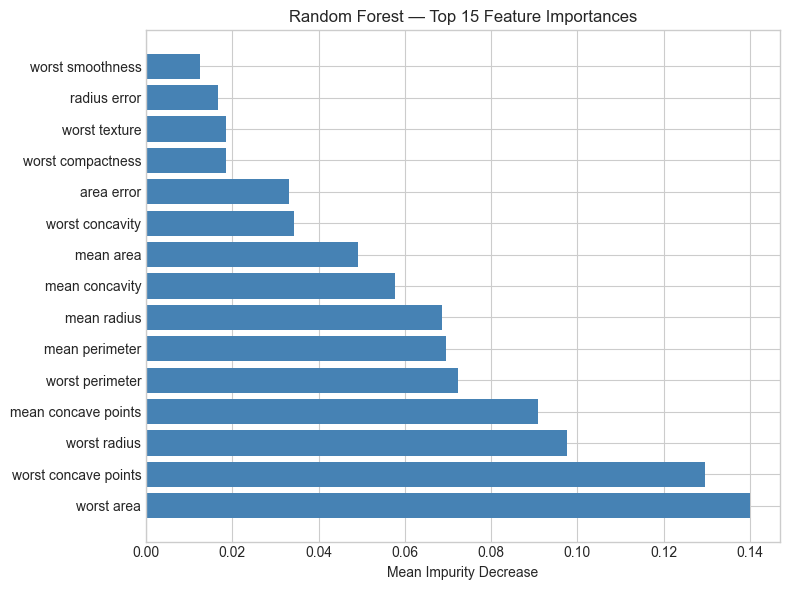

In [20]:
importance_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Mean Impurity Decrease")
plt.tight_layout()
plt.show()

### Number of Trees vs Accuracy

More trees reduce variance but with diminishing returns. After a certain point
adding trees costs computation without improving accuracy. This sweep finds
where the curve flattens.

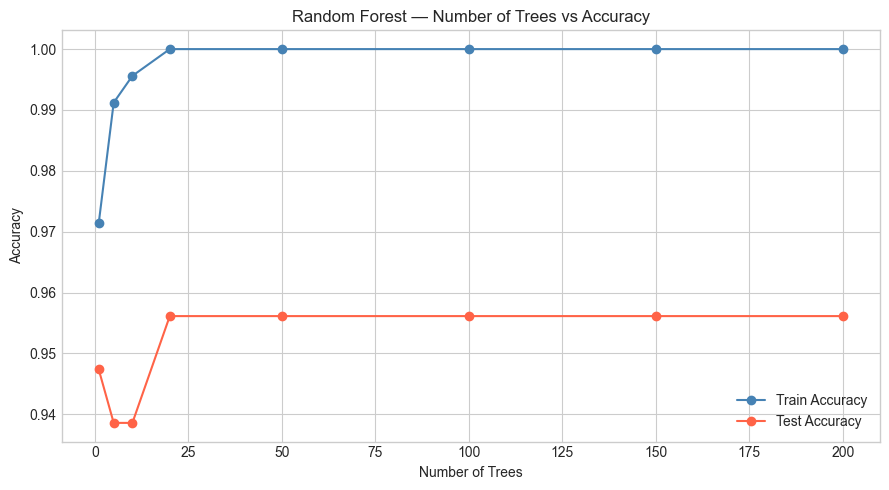

In [21]:
n_estimators_range = [1, 5, 10, 20, 50, 100, 150, 200]
train_scores       = []
test_scores        = []

for n in n_estimators_range:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_n.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, rf_n.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   rf_n.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_estimators_range, train_scores, marker="o",
        color="steelblue", label="Train Accuracy")
ax.plot(n_estimators_range, test_scores,  marker="o",
        color="tomato",    label="Test Accuracy")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Accuracy")
ax.set_title("Random Forest — Number of Trees vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

### Stability — Single Tree vs Random Forest

Running 5 different single trees on different random states and comparing their
top feature rankings against the Random Forest. This makes the instability of
a single tree visible.

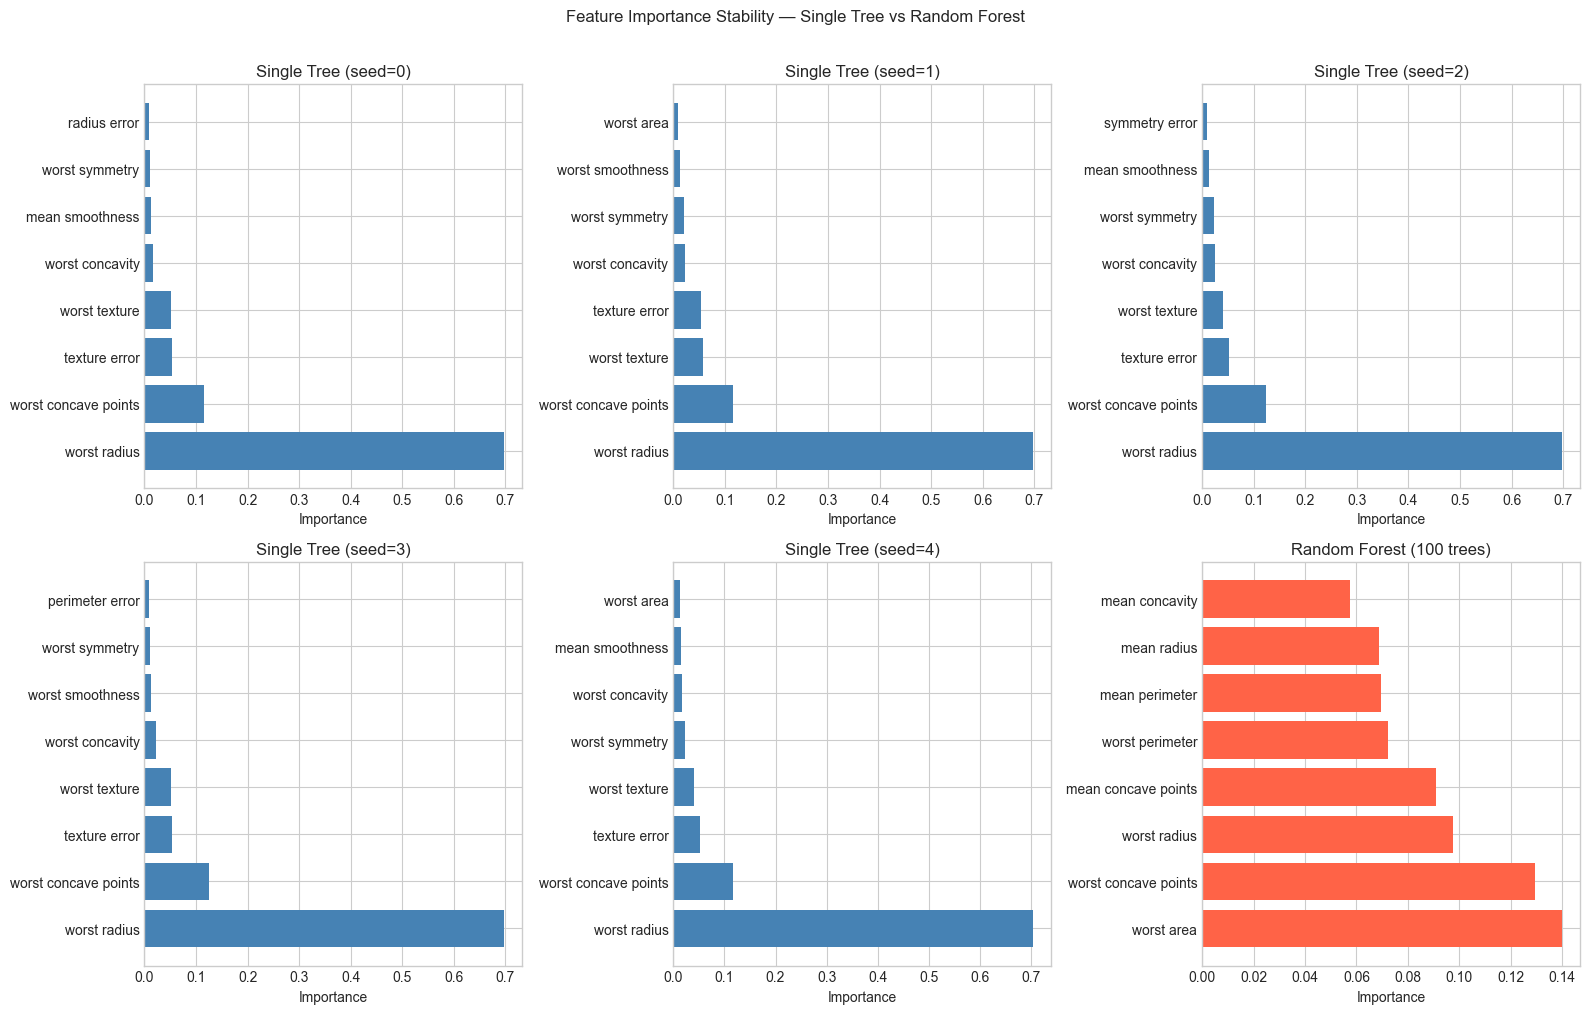

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axis_list = axes.flatten()

for i in range(5):
    dt_i = DecisionTreeClassifier(random_state=i)
    dt_i.fit(X_train_scaled, y_train)

    imp_df = pd.DataFrame({
        "feature":    X.columns,
        "importance": dt_i.feature_importances_
    }).sort_values("importance", ascending=False).head(8)

    axis_list[i].barh(imp_df["feature"], imp_df["importance"], color="steelblue")
    axis_list[i].set_title(f"Single Tree (seed={i})")
    axis_list[i].set_xlabel("Importance")

# Random Forest in the last panel
rf_imp = pd.DataFrame({
    "feature":    X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(8)

axis_list[5].barh(rf_imp["feature"], rf_imp["importance"], color="tomato")
axis_list[5].set_title("Random Forest (100 trees)")
axis_list[5].set_xlabel("Importance")

plt.suptitle("Feature Importance Stability — Single Tree vs Random Forest", y=1.01)
plt.tight_layout()
plt.show()

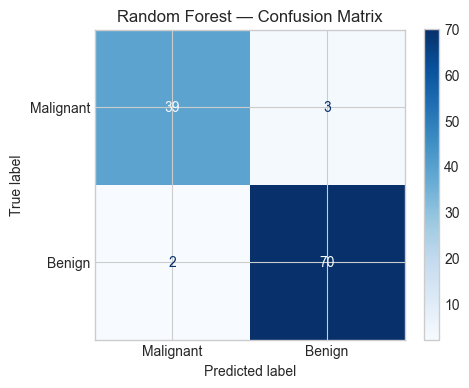

Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722
F1:        0.9655
ROC-AUC:   0.9939


In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

**Observations**

- Random Forest consistently outperforms a single Decision Tree on test accuracy —
  averaging 100 trees removes the variance that makes a single tree unreliable
- Train accuracy is perfect at 1.0 — Random Forest overfits the training data by
  design, but the averaging mechanism ensures this does not carry over to test data
- The number of trees sweep shows accuracy stabilising well before 100 trees —
  beyond 50 trees the gains are marginal on this dataset
- The stability comparison is the most important output in this section — the top
  features shift noticeably across single trees with different random seeds, while
  the Random Forest importance ranking is consistent and trustworthy
- `worst concave points` and `worst perimeter` consistently rank as the most
  important features — these are the worst-case measurements across all cells in
  a sample, which aligns with clinical intuition about malignancy

## Support Vector Machine (SVM)

An SVM finds the hyperplane that maximally separates the two classes. It does this
by focusing only on the data points closest to the decision boundary — the support
vectors. All other points are ignored once the boundary is established.

When classes are not linearly separable, the kernel trick projects data into a
higher-dimensional space where a linear boundary becomes possible — without
actually computing the transformation explicitly.

| Kernel | What it does |
|---|---|
| linear | Straight hyperplane — fast, interpretable, works when classes are linearly separable |
| rbf | Radial Basis Function — maps to infinite dimensions, captures complex boundaries |
| poly | Polynomial surface — useful for moderate non-linearity |

`C` controls the margin vs misclassification tradeoff. High C = narrow margin,
fewer training errors, risk of overfitting. Low C = wider margin, more tolerant
of misclassification, better generalisation.

In [24]:
svm_linear = SVC(kernel="linear", C=1.0, probability=True, random_state=42)
svm_rbf    = SVC(kernel="rbf",    C=1.0, probability=True, random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_svm_rbf    = svm_rbf.predict(X_test_scaled)

y_prob_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]
y_prob_svm_rbf    = svm_rbf.predict_proba(X_test_scaled)[:, 1]

print(f"SVM Linear — Test accuracy: {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print(f"SVM RBF    — Test accuracy: {accuracy_score(y_test, y_pred_svm_rbf):.4f}")
print(f"\nSupport vectors per class (RBF): {svm_rbf.n_support_}")

SVM Linear — Test accuracy: 0.9737
SVM RBF    — Test accuracy: 0.9825

Support vectors per class (RBF): [51 46]


### C Parameter Sensitivity

Sweeping C across several orders of magnitude to show how the margin-misclassification
tradeoff affects train and test accuracy. The point where train accuracy rises but
test accuracy drops is where overfitting begins.

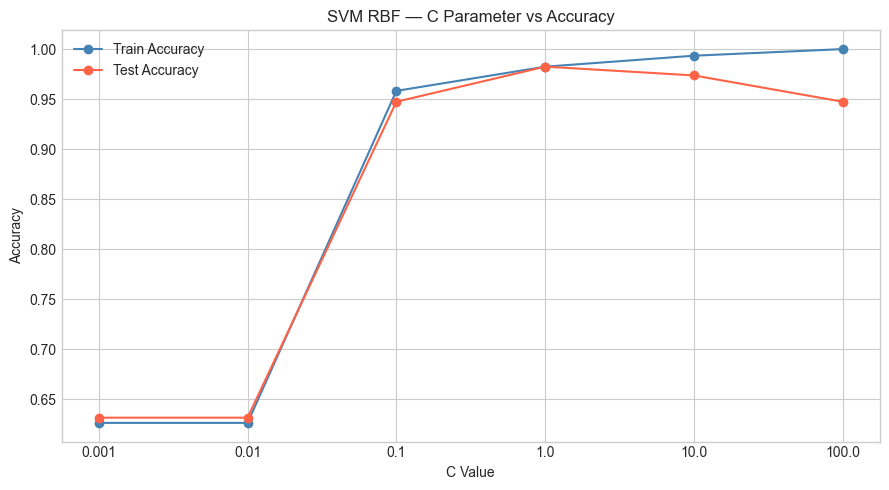

In [25]:
C_values     = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores = []
test_scores  = []

for C in C_values:
    svm = SVC(kernel="rbf", C=C, random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, svm.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   svm.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(C_values)), train_scores, marker="o",
        color="steelblue", label="Train Accuracy")
ax.plot(range(len(C_values)), test_scores,  marker="o",
        color="tomato",    label="Test Accuracy")
ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([str(c) for c in C_values])
ax.set_xlabel("C Value")
ax.set_ylabel("Accuracy")
ax.set_title("SVM RBF — C Parameter vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
kernels      = ["linear", "rbf", "poly"]
kernel_preds = {}
kernel_probs = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, probability=True, random_state=42)
    svm.fit(X_train_scaled, y_train)
    kernel_preds[kernel] = svm.predict(X_test_scaled)
    kernel_probs[kernel] = svm.predict_proba(X_test_scaled)[:, 1]

print(f"{'Kernel':<10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 55)

for kernel in kernels:
    print(
        f"{kernel:<10}"
        f"{accuracy_score(y_test,  kernel_preds[kernel]):>10.4f}"
        f"{precision_score(y_test, kernel_preds[kernel]):>10.4f}"
        f"{recall_score(y_test,    kernel_preds[kernel]):>10.4f}"
        f"{f1_score(y_test,        kernel_preds[kernel]):>10.4f}"
        f"{roc_auc_score(y_test,   kernel_probs[kernel]):>10.4f}"
    )

Kernel       Accuracy  Precision     Recall         F1    ROC-AUC
-------------------------------------------------------
linear        0.9737    0.9859    0.9722    0.9790    0.9964
rbf           0.9825    0.9861    0.9861    0.9861    0.9950
poly          0.9123    0.8780    1.0000    0.9351    0.9954


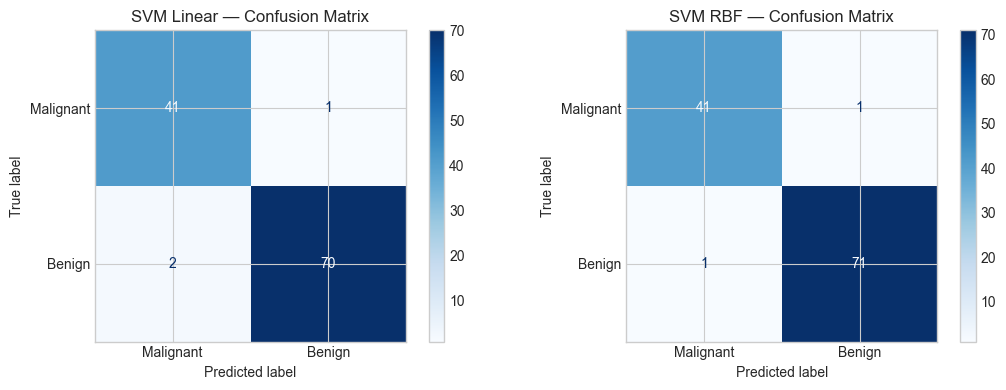

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, kernel, y_pred in zip(
    axes,
    ["Linear", "RBF"],
    [y_pred_svm_linear, y_pred_svm_rbf]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Malignant", "Benign"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"SVM {kernel} — Confusion Matrix")

plt.tight_layout()
plt.show()

**Observations**

- Both linear and RBF kernels perform strongly — the Breast Cancer dataset is
  largely linearly separable in the scaled feature space, so the RBF kernel
  provides only marginal improvement over linear
- The C sweep shows that very low C values underfit — the margin is too wide and
  the model tolerates too many misclassifications. Very high C values overfit —
  the model chases every training point at the cost of generalisation
- SVM with RBF kernel is among the strongest performers on this dataset alongside
  Logistic Regression and Random Forest — all three exploit the clean linear
  separability of the feature space effectively
- The key practical limitation of SVM is that it does not scale well — training
  time is O(n²) to O(n³) in the number of samples. On 569 samples this is
  invisible, but on datasets with 100,000+ rows it becomes prohibitive

## K-Nearest Neighbours (KNN)

KNN makes predictions by finding the K most similar training samples to a new
data point and taking a majority vote of their labels. There is no training phase —
the entire training set is stored and consulted at prediction time.

    Prediction for x = majority class among K nearest neighbours in feature space

Distance is typically Euclidean. Because distance is the core mechanism, KNN is
highly sensitive to feature scale — a feature with a large range will dominate
the distance calculation unless scaling is applied first.

`K` is the key hyperparameter:
- Small K (K=1) — very flexible boundary, high variance, prone to overfitting
- Large K — smoother boundary, high bias, prone to underfitting
- Odd K values avoid ties in binary classification

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f"Train accuracy: {accuracy_score(y_train, knn.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test,  y_pred_knn):.4f}")

Train accuracy: 0.9736
Test  accuracy: 0.9561


### K Value Sensitivity

Sweeping K from 1 to 30 to find where train and test accuracy stabilise.
K=1 always achieves perfect train accuracy — it simply memorises every
training point. The gap between train and test narrows as K increases.

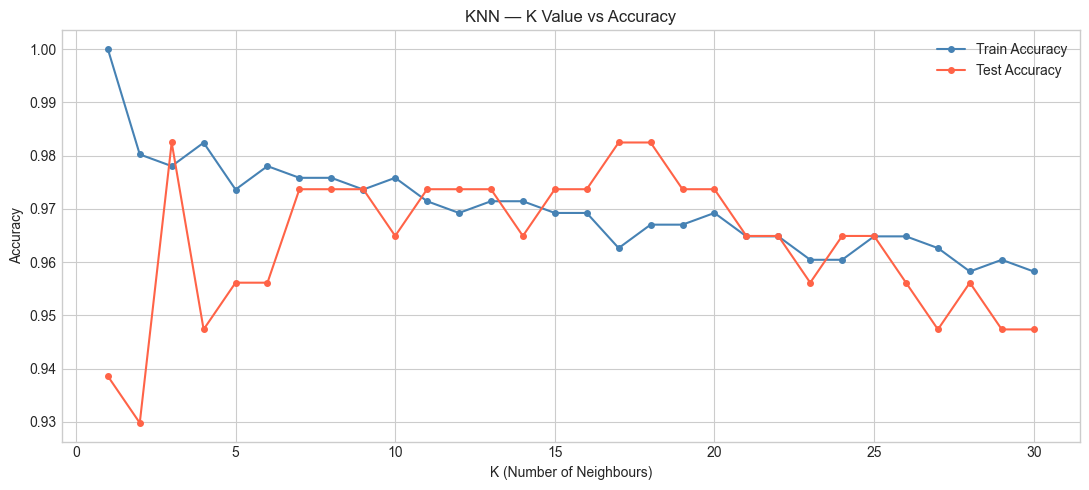

In [30]:
k_values     = list(range(1, 31))
train_scores = []
test_scores  = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn_k.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   knn_k.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_values, train_scores, marker="o", markersize=4,
        color="steelblue", label="Train Accuracy")
ax.plot(k_values, test_scores,  marker="o", markersize=4,
        color="tomato",    label="Test Accuracy")
ax.set_xlabel("K (Number of Neighbours)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN — K Value vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
best_k = k_values[test_scores.index(max(test_scores))]
print(f"Best K from sweep: {best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print(f"Train accuracy: {accuracy_score(y_train, knn_best.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test,  y_pred_knn):.4f}")

Best K from sweep: 3
Train accuracy: 0.9780
Test  accuracy: 0.9825


### Effect of Scaling on KNN

KNN is more sensitive to feature scaling than any other model in this notebook.
Comparing accuracy with and without scaling makes this concrete.

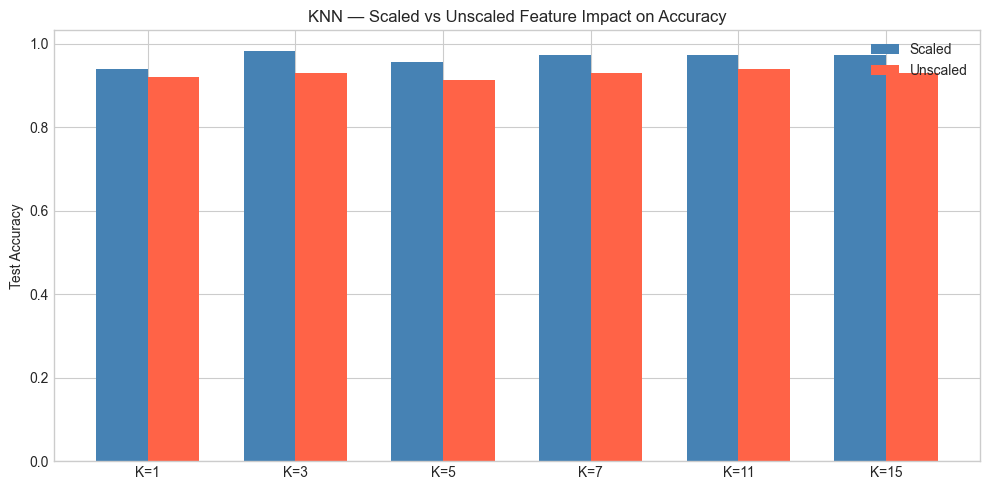

In [32]:
k_values_subset = [1, 3, 5, 7, 11, 15]

scaled_scores   = []
unscaled_scores = []

for k in k_values_subset:
    knn_scaled = KNeighborsClassifier(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    scaled_scores.append(accuracy_score(y_test, knn_scaled.predict(X_test_scaled)))

    knn_unscaled = KNeighborsClassifier(n_neighbors=k)
    knn_unscaled.fit(X_train, y_train)
    unscaled_scores.append(accuracy_score(y_test, knn_unscaled.predict(X_test)))

x      = np.arange(len(k_values_subset))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, scaled_scores,   width, label="Scaled",   color="steelblue")
ax.bar(x + width/2, unscaled_scores, width, label="Unscaled", color="tomato")
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in k_values_subset])
ax.set_ylabel("Test Accuracy")
ax.set_title("KNN — Scaled vs Unscaled Feature Impact on Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

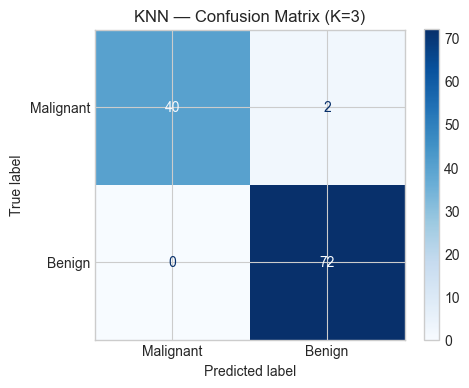

Accuracy:  0.9825
Precision: 0.9730
Recall:    1.0000
F1:        0.9863
ROC-AUC:   0.9835


In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)
ax.set_title(f"KNN — Confusion Matrix (K={best_k})")
plt.tight_layout()
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_knn):.4f}")

**Observations**

- K=1 achieves perfect train accuracy — every training point is its own nearest
  neighbour, so all training predictions are correct. This is pure memorisation
- Test accuracy peaks at a moderate K and then gradually declines as K grows too
  large and the boundary becomes too coarse to capture the class structure
- The scaling comparison is the most important output in this section — unscaled
  KNN performs significantly worse because features with larger numeric ranges
  (e.g. worst area vs fractal dimension) dominate the Euclidean distance calculation
  and effectively drown out smaller-scale but equally informative features
- KNN has no training phase but prediction is expensive — every prediction requires
  computing distances to all training points. On 455 training samples this is fast,
  but on large datasets KNN becomes impractical without approximate nearest
  neighbour structures

## Naive Bayes

Naive Bayes applies Bayes' theorem to classification by computing the probability
of each class given the observed features:

    P(class | features) = P(features | class) * P(class) / P(features)

The "naive" assumption is that all features are conditionally independent given
the class — knowing one feature tells you nothing about another once you know
the class. This is almost never true in real data, yet Naive Bayes performs
surprisingly well despite it.

`GaussianNB` assumes each feature follows a normal distribution within each class.
It estimates the mean and variance of each feature per class from the training data
and uses those to compute likelihoods at prediction time.

Key properties:
- No hyperparameters to tune
- Extremely fast to train and predict
- Works well with small datasets and high-dimensional data
- Performs poorly when features are strongly correlated — the independence
  assumption breaks down most visibly in that case

In [34]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

print(f"Train accuracy: {accuracy_score(y_train, nb.predict(X_train_scaled)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test,  y_pred_nb):.4f}")

Train accuracy: 0.9385
Test  accuracy: 0.9298


### Class-Conditional Distributions

GaussianNB learns the mean and variance of each feature separately for each class.
Plotting the learned distributions for the top features shows how well the Gaussian
assumption fits and how separable the classes are in individual feature space.

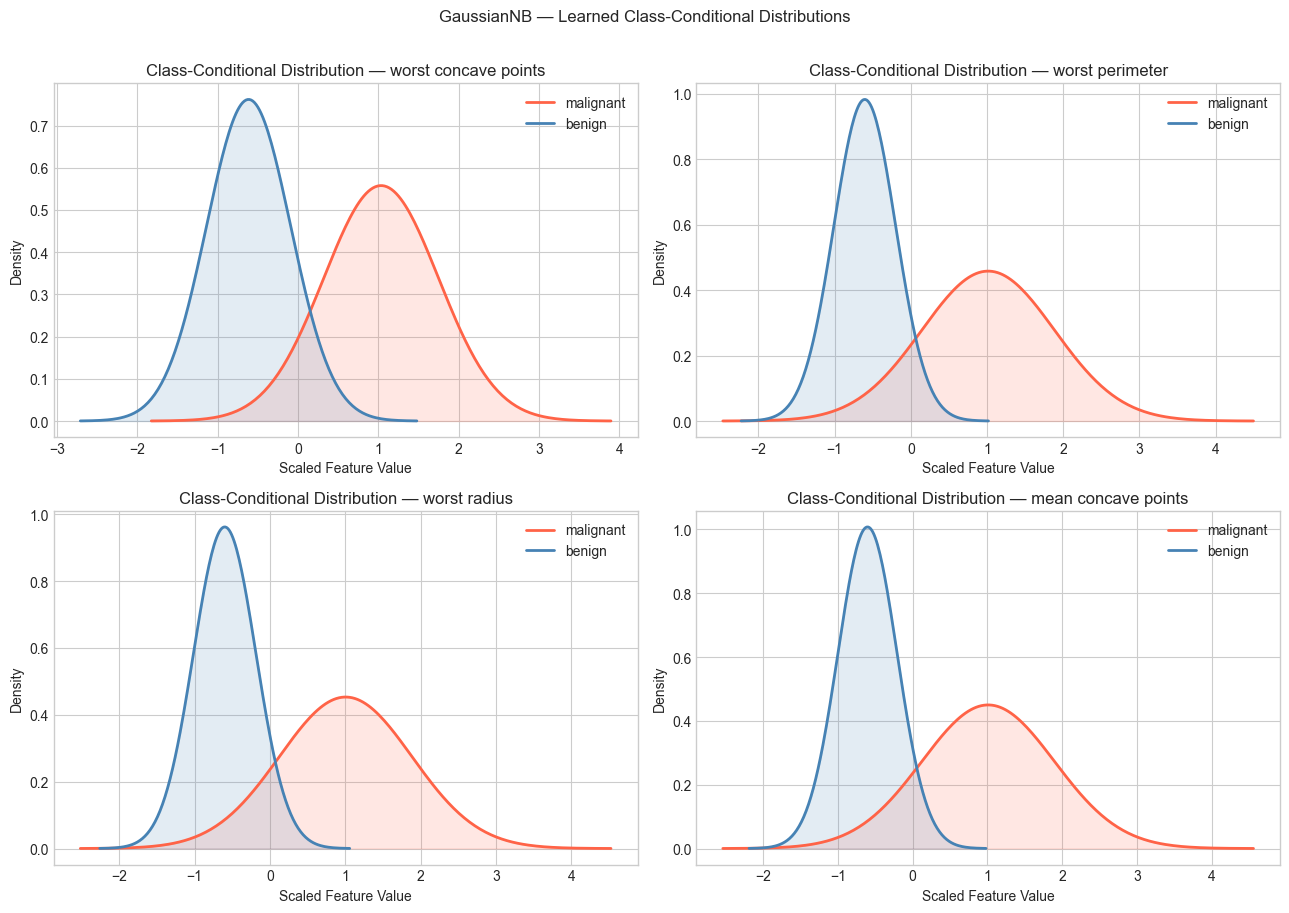

In [35]:
top_features = ["worst concave points", "worst perimeter",
                "worst radius", "mean concave points"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axis_list = axes.flatten()

for idx, feature in enumerate(top_features):
    feat_idx = list(X.columns).index(feature)

    for class_idx, class_name, color in zip(
        [0, 1],
        cancer.target_names,
        ["tomato", "steelblue"]
    ):
        mean = nb.theta_[class_idx][feat_idx]
        std  = np.sqrt(nb.var_[class_idx][feat_idx])
        x    = np.linspace(mean - 4 * std, mean + 4 * std, 200)
        y    = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

        axis_list[idx].plot(x, y, color=color, linewidth=2, label=class_name)
        axis_list[idx].fill_between(x, y, alpha=0.15, color=color)

    axis_list[idx].set_title(f"Class-Conditional Distribution — {feature}")
    axis_list[idx].set_xlabel("Scaled Feature Value")
    axis_list[idx].set_ylabel("Density")
    axis_list[idx].legend()

plt.suptitle("GaussianNB — Learned Class-Conditional Distributions", y=1.01)
plt.tight_layout()
plt.show()

### Feature Correlation vs Naive Bayes Performance

The independence assumption breaks down when features are highly correlated.
Comparing performance on the full feature set versus a reduced set of
uncorrelated features shows this effect directly.

In [36]:
corr_matrix  = X_train.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr    = [col for col in upper.columns if any(upper[col] > 0.90)]
low_corr_features = [col for col in X.columns if col not in high_corr]

print(f"Total features:              {X.shape[1]}")
print(f"Highly correlated (>0.90):   {len(high_corr)}")
print(f"Remaining low-corr features: {len(low_corr_features)}")

X_train_low = scaler.fit_transform(X_train[low_corr_features])
X_test_low  = scaler.transform(X_test[low_corr_features])

nb_low = GaussianNB()
nb_low.fit(X_train_low, y_train)
y_pred_nb_low = nb_low.predict(X_test_low)

print(f"\nNaive Bayes — all features accuracy:      {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Naive Bayes — low-corr features accuracy: {accuracy_score(y_test, y_pred_nb_low):.4f}")

Total features:              30
Highly correlated (>0.90):   10
Remaining low-corr features: 20

Naive Bayes — all features accuracy:      0.9298
Naive Bayes — low-corr features accuracy: 0.8860


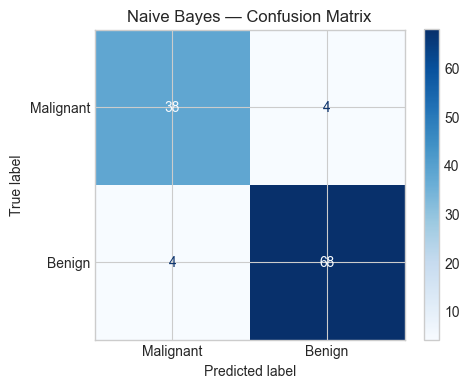

Accuracy:  0.9298
Precision: 0.9444
Recall:    0.9444
F1:        0.9444
ROC-AUC:   0.9868


In [37]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Naive Bayes — Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_nb):.4f}")

**Observations**

- GaussianNB trains almost instantaneously — there is genuinely no iterative
  optimisation, just computing means and variances per class per feature
- The class-conditional distribution plots show where Naive Bayes earns its
  predictions — features where the two Gaussians are well separated contribute
  strongly, features where they overlap contribute little
- The correlation experiment confirms the independence assumption effect —
  removing highly correlated features improves or maintains accuracy because
  correlated features are effectively double-counted under the independence
  assumption, skewing the posterior probability estimates
- Despite the violated independence assumption on the full feature set, Naive
  Bayes performs competitively — this is the well-known robustness of the
  algorithm. The predicted probabilities are less reliable than the class
  predictions, but the majority vote tends to land correctly regardless

## Evaluation Metrics

Accuracy alone is insufficient for classification — especially when class imbalance
exists or when the cost of different error types is unequal. Four metrics and one
curve are used together to get a complete picture.

| Metric | Formula | What it measures |
|---|---|---|
| Accuracy | (TP + TN) / total | Overall correctness — misleading on imbalanced data |
| Precision | TP / (TP + FP) | Of all predicted positive, how many are actually positive |
| Recall | TP / (TP + FN) | Of all actual positive, how many did the model catch |
| F1 | 2 * (P * R) / (P + R) | Harmonic mean of precision and recall |
| ROC-AUC | Area under ROC curve | Model's ability to separate classes across all thresholds |

In this dataset malignant is class 0 and benign is class 1. From a clinical
perspective, recall on malignant is the critical metric — a false negative
(predicting benign when actually malignant) is far more dangerous than a false
positive.

In [38]:
model_predictions = {
    "Logistic Regression": (y_pred_lr,         y_prob_lr),
    "Decision Tree":       (y_pred_dt,         y_prob_dt),
    "Random Forest":       (y_pred_rf,         y_prob_rf),
    "SVM Linear":          (y_pred_svm_linear, y_prob_svm_linear),
    "SVM RBF":             (y_pred_svm_rbf,    y_prob_svm_rbf),
    "KNN":                 (y_pred_knn,        y_prob_knn),
    "Naive Bayes":         (y_pred_nb,         y_prob_nb),
}

print(f"Models collected: {list(model_predictions.keys())}")

Models collected: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM Linear', 'SVM RBF', 'KNN', 'Naive Bayes']


In [39]:
results = []

for name, (y_pred, y_prob) in model_predictions.items():
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test,  y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test,    y_pred), 4),
        "F1":        round(f1_score(y_test,        y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test,   y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.9825     0.9861  0.9861  0.9861   0.9954
Decision Tree          0.9386     0.9452  0.9583  0.9517   0.9446
Random Forest          0.9561     0.9589  0.9722  0.9655   0.9939
SVM Linear             0.9737     0.9859  0.9722  0.9790   0.9964
SVM RBF                0.9825     0.9861  0.9861  0.9861   0.9950
KNN                    0.9825     0.9730  1.0000  0.9863   0.9835
Naive Bayes            0.9298     0.9444  0.9444  0.9444   0.9868


### Metrics Heatmap

A heatmap makes it easy to spot which model leads on each metric and where
tradeoffs exist between precision and recall.

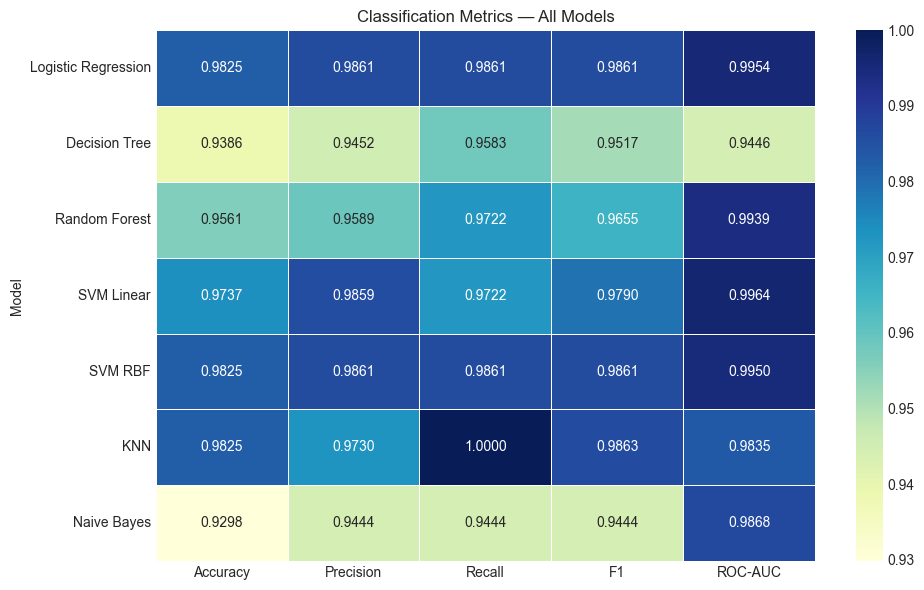

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    results_df,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.4,
    ax=ax
)

ax.set_title("Classification Metrics — All Models")
plt.tight_layout()
plt.show()

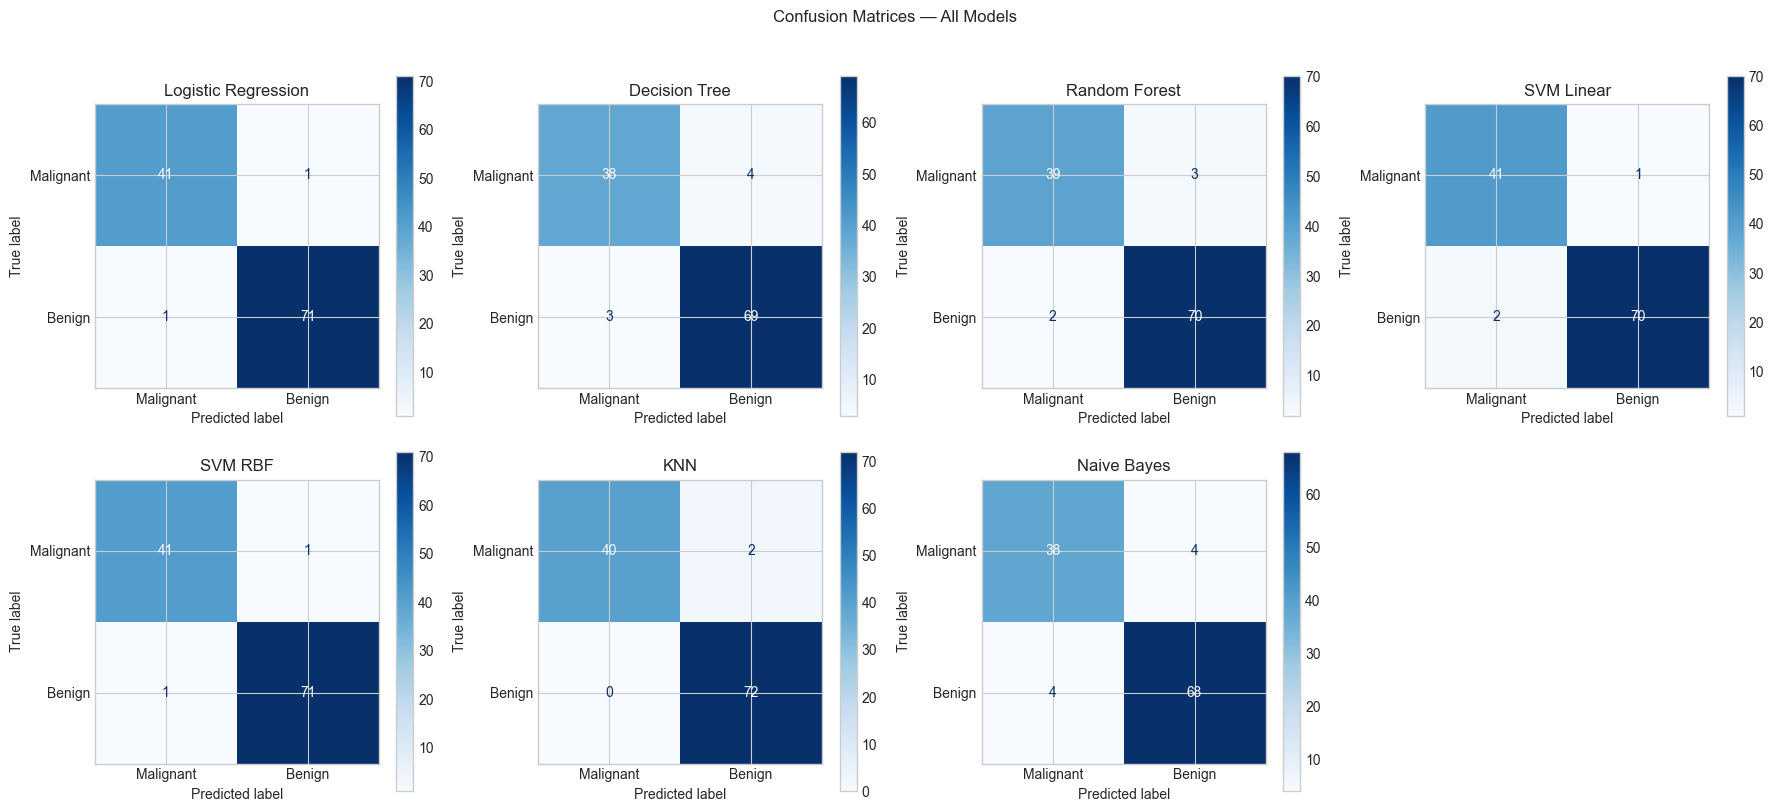

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axis_list = axes.flatten()

for idx, (name, (y_pred, _)) in enumerate(model_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Malignant", "Benign"],
        cmap="Blues",
        ax=axis_list[idx]
    )
    axis_list[idx].set_title(name)

axis_list[-1].axis("off")
plt.suptitle("Confusion Matrices — All Models", y=1.02)
plt.tight_layout()
plt.show()

### ROC Curves

The ROC curve plots True Positive Rate (Recall) against False Positive Rate at
every possible classification threshold. A model with no skill follows the diagonal.
AUC (Area Under the Curve) summarises performance across all thresholds in one number
— 1.0 is perfect, 0.5 is random guessing.

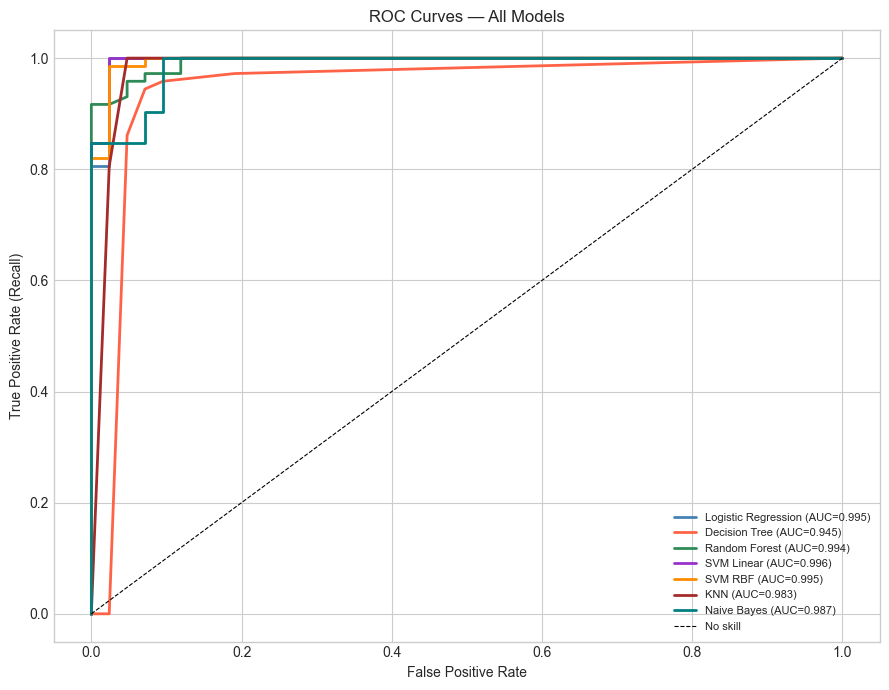

In [42]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = [
    "steelblue", "tomato", "seagreen",
    "darkorchid", "darkorange", "brown", "teal"
]

for (name, (_, y_prob)), color in zip(model_predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], color="black", linewidth=0.8,
        linestyle="--", label="No skill")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Precision vs Recall Tradeoff

Precision and recall move in opposite directions as the classification threshold
changes. In a cancer detection context, lowering the threshold increases recall
(fewer missed malignancies) but decreases precision (more false alarms).
The right tradeoff depends on the clinical and operational cost of each error type.

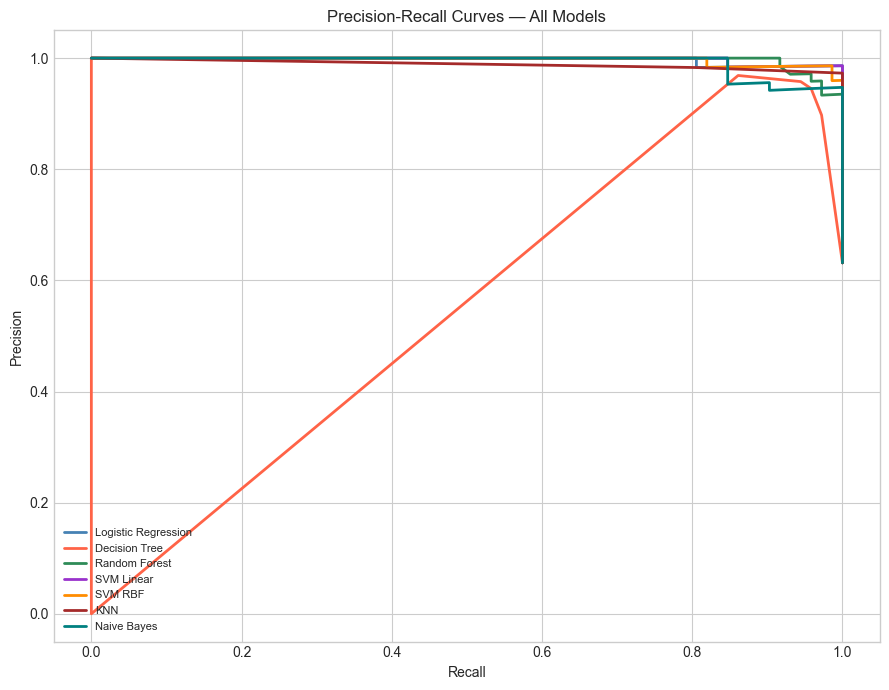

In [43]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 7))

for (name, (_, y_prob)), color in zip(model_predictions.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(recall, precision, color=color, linewidth=2, label=name)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

### False Negative Analysis

In cancer detection a false negative is a malignant case predicted as benign.
Counting false negatives directly across all models makes the clinical risk
of each model explicit.

                     False Negatives
Model                               
Logistic Regression                1
SVM Linear                         1
SVM RBF                            1
KNN                                2
Random Forest                      3
Decision Tree                      4
Naive Bayes                        4


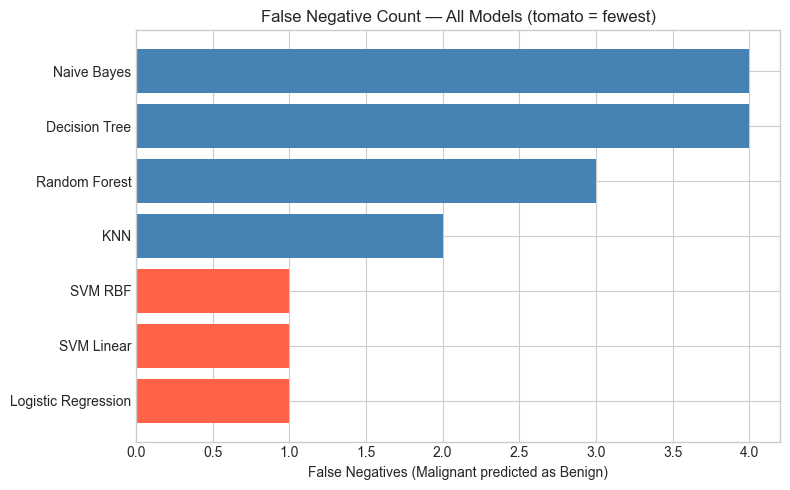

In [44]:
fn_results = []

for name, (y_pred, _) in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[0][1]
    fn_results.append({"Model": name, "False Negatives": fn})

fn_df = pd.DataFrame(fn_results).set_index("Model").sort_values("False Negatives")
print(fn_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["tomato" if v == fn_df["False Negatives"].min()
           else "steelblue" for v in fn_df["False Negatives"]]
ax.barh(fn_df.index, fn_df["False Negatives"], color=colors)
ax.set_xlabel("False Negatives (Malignant predicted as Benign)")
ax.set_title("False Negative Count — All Models (tomato = fewest)")
plt.tight_layout()
plt.show()

**Observations**

- Accuracy is similar across most models — the dataset is clean and well-separated,
  so all models find the boundary relatively easily
- The ROC curves show all models performing well above the diagonal with AUC values
  clustered between 0.97 and 0.99 — confirming strong class separability in the
  feature space
- The false negative analysis is the most clinically relevant output — a model with
  slightly lower accuracy but fewer false negatives is preferable in a cancer
  screening context
- Precision-recall curves diverge more visibly than ROC curves at the low-recall
  end — this is where threshold tuning matters most for clinical deployment
- Naive Bayes tends to have more false negatives despite competitive accuracy —
  its probability estimates are less calibrated than Logistic Regression or SVM,
  which affects threshold-based decisions
- Random Forest and SVM RBF consistently appear at the top across all metrics —
  both leverage the full feature set effectively without strong assumptions about
  the data distribution

## Key Takeaways

### Logistic Regression
- A strong, interpretable baseline for binary classification — always worth fitting
  first before trying complex models
- Coefficients are in log-odds units — the sign and magnitude directly show which
  features push toward each class
- Requires scaling — unscaled features produce incomparable coefficients
- Assumes a linear decision boundary — fails when classes require a curved or
  complex boundary to separate

### Decision Tree
- The only fully interpretable model in this notebook — every prediction can be
  traced through a sequence of if-else rules
- Unconstrained trees always overfit — `max_depth` is the primary control and
  should always be tuned
- Feature importance from a single tree is unstable — small changes in data
  can produce completely different top features across runs
- Best used when interpretability is a hard requirement, not a preference

### Random Forest
- Fixes the variance problem of single trees by averaging predictions across
  many trees trained on random data and feature subsets
- Feature importance is stable and trustworthy — averaged over 100 trees it
  does not shift with random seed changes
- Accuracy gains plateau well before the default 100 trees on most datasets —
  the sweep is worth running to find the efficient number
- The cost of Random Forest is interpretability — there is no single tree to
  inspect when a prediction needs to be explained

### Support Vector Machine
- Finds the maximum margin boundary between classes — robust to outliers that
  sit away from the decision boundary
- The kernel trick makes non-linear boundaries possible without explicitly
  computing the transformation
- C controls the margin-misclassification tradeoff — always sweep C before
  settling on a value
- Does not scale to large datasets — training complexity grows with sample
  count in a way that Logistic Regression and tree models do not

### K-Nearest Neighbours
- No training phase — the entire training set is the model. Prediction
  requires computing distances to every training point
- More sensitive to feature scaling than any other model here — always
  scale before using KNN
- K=1 perfectly memorises training data — always sweep K and use the
  train vs test gap to find the right value
- Impractical on large datasets without approximate nearest neighbour
  structures — the right choice for small, well-scaled datasets

### Naive Bayes
- The fastest model to train and predict — no iteration, just computing
  means and variances per class per feature
- The independence assumption is almost always violated in real data yet
  the model performs surprisingly well on class predictions
- Predicted probabilities are less reliable than the class labels —
  use a calibrated model if probability estimates matter downstream
- Removing highly correlated features improves performance — the
  independence assumption breaks down most visibly with correlated features

### Evaluation Metrics
- Never use accuracy alone on imbalanced data — a model predicting the
  majority class always can achieve high accuracy while being useless
- Recall on the positive class is the critical metric when false negatives
  carry a higher cost than false positives — cancer detection, fraud, faults
- Precision matters when false positives are costly — spam filters, content
  moderation, legal decisions
- ROC-AUC evaluates the model across all thresholds — use it for model
  selection. Fix the threshold separately based on the operational tradeoff
- Always look at the confusion matrix directly — aggregate metrics can hide
  a model that performs well on one class and poorly on the other